In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
from scipy.io import wavfile
import os
from icecream import ic

In [2]:
# define the file paths and load them
CHIRP_PATH = './lab_tests/240103/chirp_trial1.wav'
PARALLEL_PATH = './lab_tests/240103/parallel_trial2.wav'

chirp_fs, chirp_data = wavfile.read(CHIRP_PATH)
ll_fs, ll_data = wavfile.read(PARALLEL_PATH)

In [11]:
# convert data type of ll_data to reduce memory demands
ll_data = ll_data.astype(np.float32)

In [4]:
ic(chirp_fs)
ic(ll_fs)

ic| chirp_fs: 102400
ic| ll_fs: 102400


102400

## chirp

In [3]:
# visualize the chirp recording
chirp_duration = len(chirp_data)/chirp_fs
chirp_time = np.linspace(0, chirp_duration, len(chirp_data))

In [4]:
# calculate power density spectrum of signal
chirp_freqs, chirp_Pxx = sc.signal.periodogram(x=chirp_data, fs=chirp_fs, return_onesided=True, scaling='density')
chirp_freqs = chirp_freqs/1000 # scale to kHz

In [5]:
# create source signal array
# read .wav file
gt_fs, ground_truth_chirp = wavfile.read('./chirps/231128_groundtruth_15.0-45.0kHz_logarithmic.wav')

gt_duration = len(ground_truth_chirp)/gt_fs
gt_time = np.linspace(0, gt_duration, len(ground_truth_chirp))

# calculate power density spectrum of signal
gt_freqs, gt_Pxx = sc.signal.periodogram(x=ground_truth_chirp, fs=gt_fs, return_onesided=True, scaling='density')
gt_freqs = gt_freqs/1000 # scale to kHz

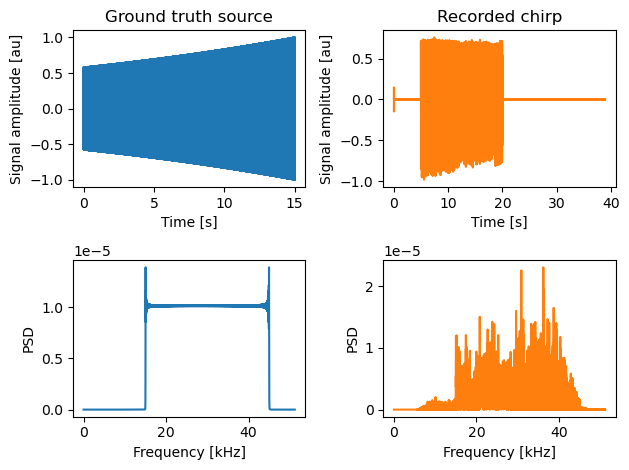

In [6]:
# plot the ground truth chirp next to this
fig, axs = plt.subplots(nrows=2, ncols=2) # first column is time domain, second column is frequency domain

# plot ground truth source signal in time and freq domain
axs[0][0].plot(gt_time, ground_truth_chirp)
axs[0][0].set_title('Ground truth source')
axs[0][0].set_xlabel('Time [s]')
axs[0][0].set_ylabel('Signal amplitude [au]')

axs[1][0].plot(gt_freqs, gt_Pxx)
axs[1][0].set_xlabel('Frequency [kHz]')
axs[1][0].set_ylabel('PSD')
axs[1][0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))


# plot the received signal in time and freq domain
axs[0][1].plot(chirp_time, chirp_data, color='tab:orange')
axs[0][1].set_title('Recorded chirp')
axs[0][1].set_xlabel('Time [s]')
axs[0][1].set_ylabel('Signal amplitude [au]')

axs[1][1].plot(chirp_freqs, chirp_Pxx, color='tab:orange')
axs[1][1].set_xlabel('Frequency [kHz]')
axs[1][1].set_ylabel('PSD')
axs[1][1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))


plt.tight_layout()
plt.show()

In [9]:
# make sure that the two signals have the same samplerate
ic(gt_fs)
ic(chirp_fs)

ic| gt_fs: 102400
ic| chirp_fs: 102400


102400

In [7]:
# deconvolve the source signal from the recorded signal

time_reversed_chirp = ground_truth_chirp[::-1]

# calculate impulse response
h_fs = gt_fs
h = sc.signal.convolve(time_reversed_chirp, chirp_data, mode='valid')
h_time = np.linspace(0, len(h)/h_fs, len(h))

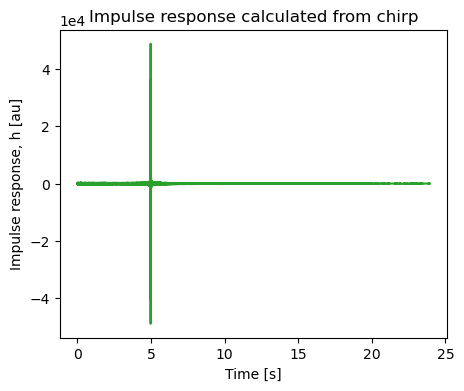

In [10]:
# plot impulse response
fig, ax = plt.subplots(figsize=(5,4))
ax.plot(h_time, h, color='tab:green')
ax.set_title('Impulse response calculated from chirp')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Impulse response, h [au]')
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))


plt.show()

## Parallel

In [12]:
# visualize the chirp recording
ll_duration = len(ll_data)/ll_fs
ll_time = np.linspace(0, ll_duration, len(ll_data))

In [14]:
start = 0
SLICE_LENGTH = ll_duration/11

c:\Users\JVietorisz\AppData\Local\anaconda3\envs\hydros\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


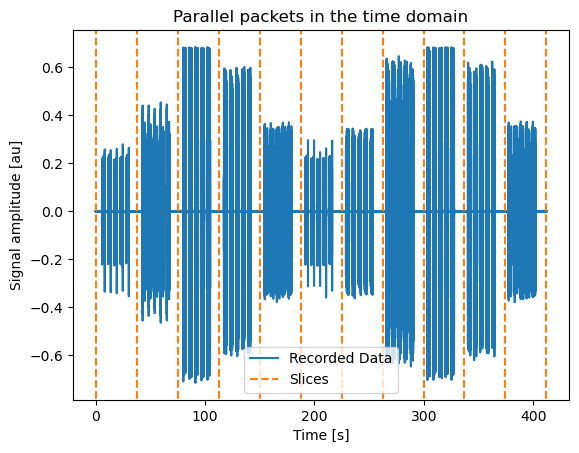

In [13]:
# xmin, xmax = 5, 10

fig, ax = plt.subplots()
ax.plot(ll_time, ll_data, label='Recorded Data')
# plot the slice locations
for slice_num in range(12):
    if slice_num == 0:
        ax.axvline(x=start + slice_num * SLICE_LENGTH, color='tab:orange', 
               linestyle='--', ymin=-1, ymax=1, label='Slices')
    else:
        ax.axvline(x=start + slice_num * SLICE_LENGTH, color='tab:orange', 
               linestyle='--', ymin=-1, ymax=1)

ax.set_title('Parallel packets in the time domain')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Signal amplitude [au]')
# ax.set_xlim(xmin, xmax)

plt.legend()
plt.show()

In [15]:
# slice array to separate each frequency
freqs = ['20_0', 25, 30, 35, '40_0', '20_1', 24, 28, 32, 36, '40_1']

slices = {}
for i, freq_kHz in enumerate(freqs):
    time_min, time_max = start + i * SLICE_LENGTH, start + (i+1)*SLICE_LENGTH
    ind_min, ind_max = int(time_min * ll_fs), int(time_max * ll_fs)

    data_slice = ll_data[ind_min : ind_max]
    time_slice = ll_time[ind_min : ind_max]
    slices[freq_kHz] = [data_slice, time_slice]

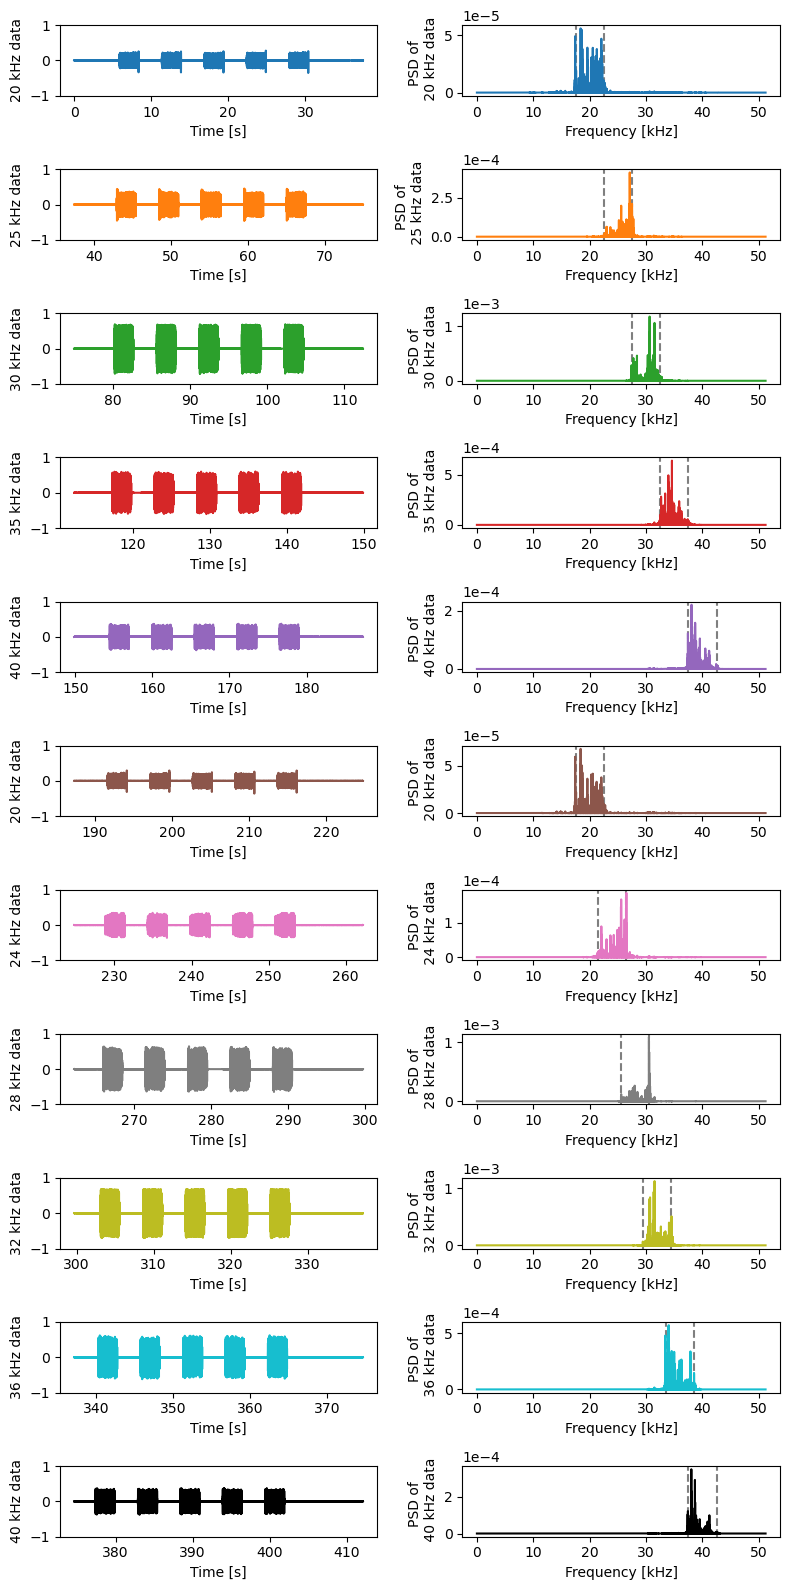

In [17]:
# plot each slice
fig, axs = plt.subplots(nrows=len(slices), ncols=2, figsize=(5, 16))

# construct list of colors so plots are easily distinguishable
import matplotlib.colors as mcolors
colors = [key for key in mcolors.TABLEAU_COLORS]
colors.append('k')

for i, freq in enumerate(slices):

    # unpack data and time arrays from hashmap value
    data = slices[freq][0]
    time = slices[freq][1]

    # plot the time-domain signals
    axs[i][0].plot(time, data, color=colors[i])
    axs[i][0].set_xlabel('Time [s]')
    freq = str(freq)
    axs[i][0].set_ylabel('{0} kHz data'.format(freq[:2]))
    axs[i][0].set_ylim(-1, 1)

    # plot the frequency domain signals (PSD)
    fs, Pxx = sc.signal.periodogram(x=data, fs=ll_fs, return_onesided=True, scaling='density')
    fs = fs/1000 # scale to kHz
    
    # plot the theoretical bandwidth limits
    axs[i][1].axvline(float(freq[:2]) - 2.5, color='tab:gray', 
               linestyle='--')
    axs[i][1].axvline(float(freq[:2]) + 2.5, color='tab:gray', 
               linestyle='--')
    # plot the actual PSD
    axs[i][1].plot(fs, Pxx, color=colors[i])
    axs[i][1].set_xlabel('Frequency [kHz]')
    axs[i][1].set_ylabel('PSD of \n {0} kHz data'.format(freq[:2]))
    axs[i][1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

        

plt.tight_layout()
plt.show()
    

In [50]:
# compute spectrogram with scipy
f, t, Sxx = sc.signal.spectrogram(ll_data, ll_fs, return_onesided=True)
f = f/1e3 # convert to kHz

freq_slice = np.where((f >= 15) & (f <= 45)) # keep only frequencies in range of interest
t_slice = np.where(t>0) # keep 1 in 100 time slices

t_slice = np.where(t%(100*(t[1]-t[0])) < 0.1) # keep 1 in 100 time slices

f = f[freq_slice]
t = t[t_slice]

ic(f.shape)
ic(t.shape)

Sxx = Sxx[freq_slice,:][0]
Sxx = Sxx[:,t_slice][:,0,:]

ic(Sxx.shape)

ic| f.shape: (75,)
ic| t.shape: (86664,)
ic| Sxx.shape: (75, 86664)


(75, 86664)

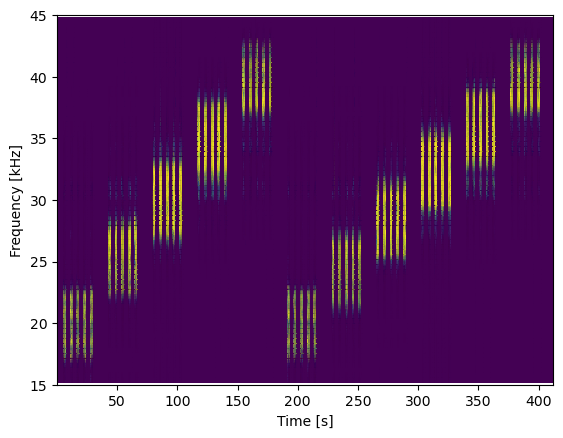

In [68]:
fig, ax = plt.subplots()

spectrogram = ax.pcolormesh(t, f, Sxx, shading='gouraud', vmin=1e-8, vmax=5e-7, cmap='viridis')
ax.set_ylabel('Frequency [kHz]')
ax.set_xlabel('Time [s]')
ax.set_ylim(15, 45)
# fig.colorbar(spectrogram)
plt.show()

In [18]:
# # create spectrogram of the packet data signal using the Hilbert Huang Transform
# import emd
# from scipy import ndimage
# import matplotlib.patches as patches

# # Run a mask sift
# imfs = emd.sift.mask_sift(ll_data, max_imfs=5)

In [19]:
# # Compute frequency statistics
# IP, IF, IA = emd.spectra.frequency_transform(imfs, ll_fs, 'hilbert')

In [20]:
# # Carrier frequency histogram definition
# freq_edges, freq_centres = emd.spectra.define_hist_bins(data_min=15e3, data_max=45e3, nbins=29, scale='linear')

In [21]:
# # Compute Hilbert-Huang spectrogram
# f, hht = emd.spectra.hilberthuang(IF, IA, freq_edges, mode='amplitude', 
#                                   sum_time=False, sum_imfs=True, 
#                                   return_sparse=True, sample_rate=ll_fs,
#                                   return_Gb_limit=10)                        # f is a vector of histogram bin centers of each frequency
#                                                                             # hht is a 2D array containing the transform


In [22]:
# time_centres = np.linspace(0, np.max(ll_time), int(len(ll_time)/100)) - 0.5 # create array of time bin centers

In [23]:
# # plot the Hilbert-Huang Spectrum

# emd.plotting.plot_hilberthuang(hht, time_centres, freq_centres, 
#                                cmap='viridis', time_lims=(0, 450))

Power equalization

C:\Users\JVietorisz\AppData\Local\Temp\ipykernel_14896\1397216857.py:12: RuntimeWarning: invalid value encountered in sqrt
  return a + b*np.sqrt(c * (xdata - d))
ic| popt_sqrt: array([1.59051233e-05, 5.61639510e-01, 6.33230430e-03, 5.05832767e-05])


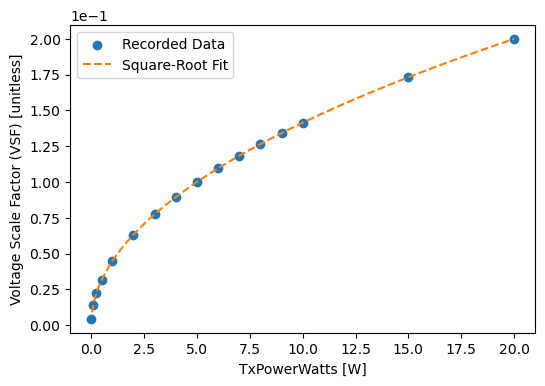

In [105]:
TxPowerWatts = [0.01, 0.1, 0.25, 0.5, 
                1.,2.,3.,4.,
                5.,6.,7.,8.,
                9.,10., 15., 20.]
scale_factor = [4.472e-3, 1.4142e-2, 2.2361e-2, 3.1623e-2, 
                4.4721e-2, 6.3246e-2, 7.7460e-2, 8.9443e-2,
                1.0e-1, 1.09545e-1, 1.178322e-1, 1.26491e-1,
                1.34164e-1, 1.41421e-1, 1.73e-1, 2.0e-1 ] 


def fit_sqrt(xdata, a,b,c,d):
    return a + b*np.sqrt(c * (xdata - d))

popt_sqrt, _ = sc.optimize.curve_fit(f=fit_sqrt, xdata=TxPowerWatts, ydata=scale_factor, 
                                   maxfev=int(1e4), p0=[0, 1, 1, 0])

ic(popt_sqrt)

x = np.linspace(0, 20, 500)
sqrt_fit = fit_sqrt(x, *popt_sqrt)

fig, ax = plt.subplots(figsize=(6,4))

# plot as scale factor versus power
ax.scatter(TxPowerWatts, scale_factor, label='Recorded Data')
ax.plot(x, sqrt_fit, linestyle='--', color='tab:orange', label='Square-Root Fit')
ax.set_xlabel('TxPowerWatts [W]')
ax.set_ylabel('Voltage Scale Factor (VSF) [unitless]')
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.legend()
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

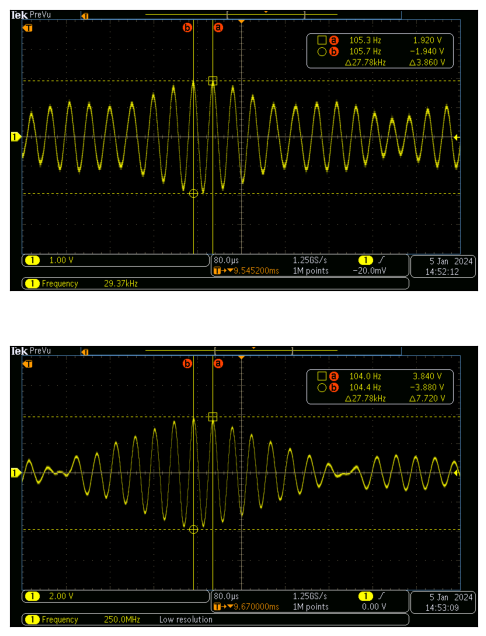

In [108]:
# load images from scope
im1 = plt.imread('./lab_tests/scope_images/scope_2W_28kHz.png')
im2 = plt.imread('./lab_tests/scope_images/scope_8W_28kHz.png')

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 8))

axs[0].imshow(im1)
axs[0].get_xaxis().set_visible(False)
axs[0].get_yaxis().set_visible(False)
axs[1].imshow(im2)
axs[1].get_xaxis().set_visible(False)
axs[1].get_yaxis().set_visible(False)
plt.show
